# ABC Company Employee Analysis

Project analyze employee data from the ABC company. The given dataset contains 458 rows and 9 columns.
The project is to do below:
1. Data preprocessing
2. Data analysis
3. Data visualization
4. Extracting meaningful insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("ABC Company.xlsx")
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


####  1. Data preprocessing
* Correct the height column
* Handling missing values.

In [6]:
np.random.seed(42)
df['Height']= np.random.randint(150,181, size=len(df))

In [9]:
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [26]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,156,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,169,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,178,205,Boston University,2836186.0
3,R.J. Hunter,Boston Celtics,28,SG,22,164,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,160,231,NaN,5000000.0


## 1. Employee distribution by team

In [27]:
team_dist = df['Team'].value_counts()
team_percent = (team_dist / len(df)) * 100

print(team_dist)
print(team_percent)

Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
New York Knicks           16
Milwaukee Bucks           16
Brooklyn Nets             15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Denver Nuggets            15
Washington Wizards        15
Miami Heat                15
Charlotte Hornets         15
Atlanta Hawks             15
San Antonio Spurs         15
Houston Rockets           15
Boston Celtics            15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Sacramento Kings          15
Phoenix Suns              15
Los Angeles Lakers        15
Los Angeles Clippers      15
Golden State Warriors     15
Toronto Raptors           15
Philadelphia 76ers        15
Dallas Mavericks          15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64
Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz               

#### Graphical Representation

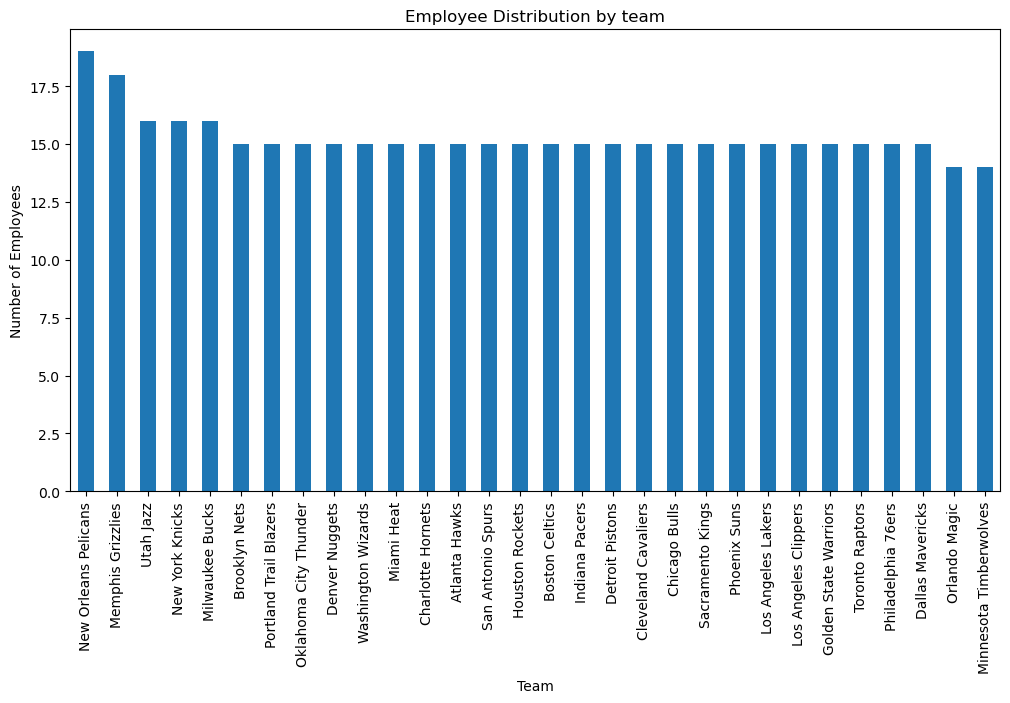

In [24]:
plt.figure(figsize=(12,6))
team_dist.plot(kind='bar')

plt.title("Employee Distribution by team")
plt.xlabel("Team")
plt.ylabel("Number of Employees")

plt.xticks(rotation=90)
plt.show()

### Insights
1. The team with the highest number of employees is "New Orleans Pelicans (Approx.4.1%)".
2. Other major teams include "Memphis Grizzlies" (Approx. 3.93%) and "Utah Jazz/New York Knicks/ Milwaukee Bucks (Approx 3.49%)
3. Employee distribution across teams is relatively balanced with slight variations.

## 2. Employee Distribution by position

In [28]:
position_dist = df['Position'].value_counts()
print(position_dist)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


#### Graphical Representation

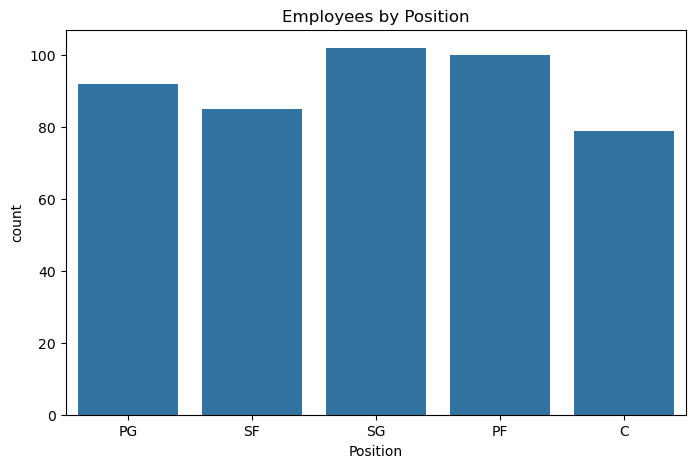

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='Position' , data=df)
plt.title("Employees by Position")
plt.show()

### Insights

1. The most common position is "Shoting Guard" with the highest number of employees.
2. This is followed by "Power Forward (PF)" and "Point Guard".
3. The least common position is "Center (C)".

## 3. Age Distribution

In [29]:
bins = [20, 25, 30, 35, 40]
labels = ['20-25', '25-30', '30-35', '35-40']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_group_dist = df['Age Group'].value_counts()
print(age_group_dist)

Age Group
20-25    179
25-30    167
30-35     68
35-40     23
Name: count, dtype: int64


#### Graphical Representation

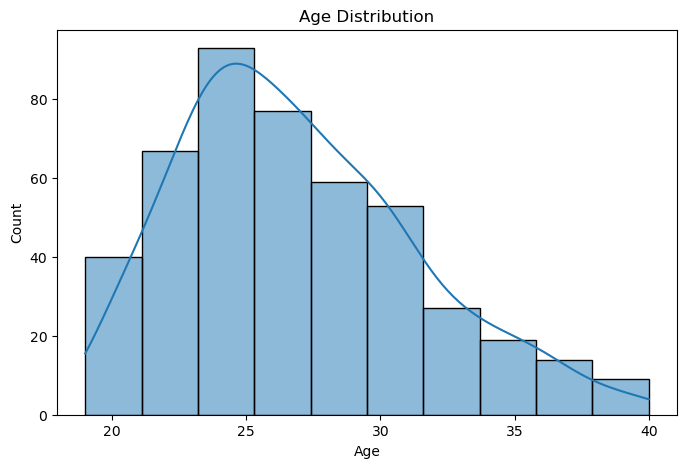

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

### Insights

1. The predominant age group is "20-25", followed closely by "25-30" years.
2. This indicates that the company has a "young workforce".
3. Very few employees are above 35, indicating limited senior-age representaion in the company.

## 4. Salary Expenditure Analysis

In [16]:
team_salary = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
position_salary = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)

print("Top Teams by Salary:\n", team_salary.head())
print("\nTop Position by Salary:\n", position_salary.head())

Top Teams by Salary:
 Team
Cleveland Cavaliers      109824875.0
Los Angeles Clippers      94854640.0
Oklahoma City Thunder     93765298.0
Golden State Warriors     88868997.0
Miami Heat                88188045.0
Name: Salary, dtype: float64

Top Position by Salary:
 Position
C     466377332.0
PG    458193715.0
PF    451069408.0
SF    410857162.0
SG    405484816.0
Name: Salary, dtype: float64


#### Graphical Representation

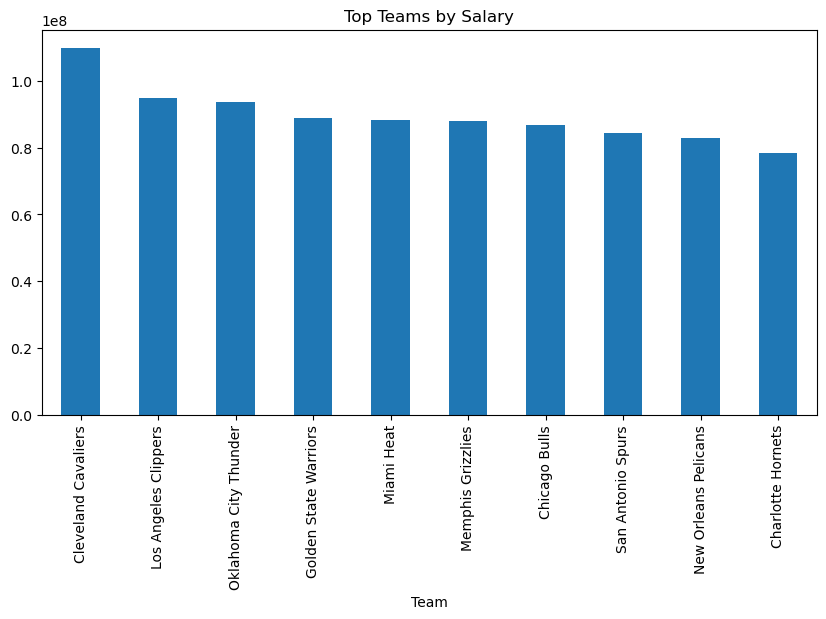

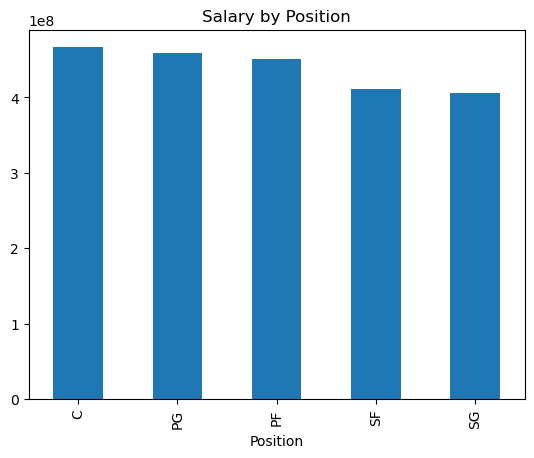

In [17]:
team_salary.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Teams by Salary")
plt.show()

position_salary.plot(kind='bar')
plt.title("Salary by Position")
plt.show()

### Insights

1. The team with the highest salary expenditure is "Cleveland Cavaliers".
2. The position with the highest salary expenditure is "Center(C)".
3. This sugegsts that certain teams and ey positions receive "Significantly higher financial investment" compared to others.

## 5. Correlation Between Age and Salary

In [19]:
correlation = df[['Age', 'Salary']].corr()
print("Correlation:", correlation)

Correlation:              Age    Salary
Age     1.000000  0.209124
Salary  0.209124  1.000000


#### Graphical Representation

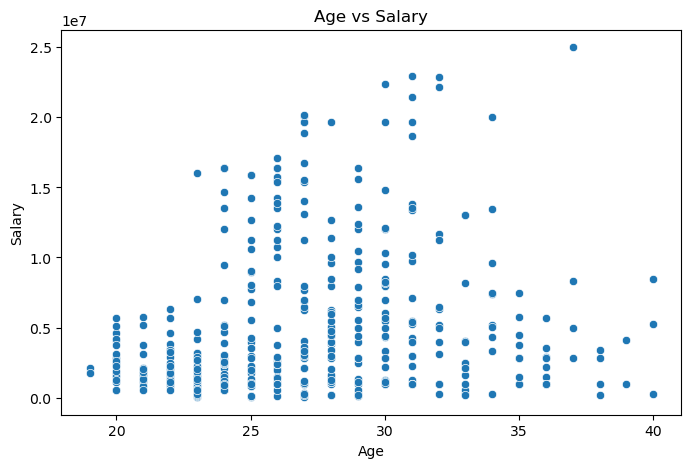

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Salary', data=df)
plt.title("Age vs Salary")
plt.show()

### Insights
1. The correlation between age and salary is "0.209".
2. This indicates a "weak positive relationship" between age and salary.
3. It suggests that factors like "performance", "role",or " experience" may influence salary more than age alone.

------------------------------------------------------------------------------------------------------------------------------